In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
n = 10000

In [ ]:
attendance = np.random.randint(40, 100, n)
study_hours = np.random.randint(1, 10, n)  # per day
gpa = np.random.uniform(4, 10, n)
classroom_interaction = np.random.randint(1, 10, n)
assignment_completion = np.random.randint(40, 100, n)

In [ ]:
dropout_prob = (
    0.3 * (attendance < 60) +
    0.25 * (study_hours < 3) +
    0.25 * (gpa < 6) +
    0.2 * (assignment_completion < 60)
)

In [ ]:
dropout_prob = dropout_prob + np.random.normal(0, 0.1, n)

In [ ]:
dropout = (dropout_prob > 0.5).astype(int)

In [ ]:
df = pd.DataFrame({
    'attendance': attendance,
    'study_hours': study_hours,
    'gpa': gpa,
    'classroom_interaction': classroom_interaction,
    'assignment_completion': assignment_completion,
    'dropout': dropout
})

df.head()

,attendance,study_hours,gpa,classroom_interaction,assignment_completion,dropout
0,78,1,5.052332,8,56,1
1,91,7,7.079276,1,74,0
2,68,9,6.552493,9,86,0
3,54,1,9.343307,8,84,0
4,82,2,6.577400,3,74,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   attendance             10000 non-null  int64  
 1   study_hours            10000 non-null  int64  
 2   gpa                    10000 non-null  float64
 3   classroom_interaction  10000 non-null  int64  
 4   assignment_completion  10000 non-null  int64  
 5   dropout                10000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


,attendance,study_hours,gpa,classroom_interaction,assignment_completion,dropout
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,69.822000,4.975100,6.990569,5.071100,69.494400,0.226800
std,17.309144,2.586958,1.728602,2.568444,17.339545,0.418783
min,40.000000,1.000000,4.000056,1.000000,40.000000,0.000000
25%,55.000000,3.000000,5.488189,3.000000,55.000000,0.000000
50%,70.000000,5.000000,6.964044,5.000000,69.000000,0.000000
75%,85.000000,7.000000,8.475819,7.000000,84.000000,0.000000
max,99.000000,9.000000,9.999356,9.000000,99.000000,1.000000


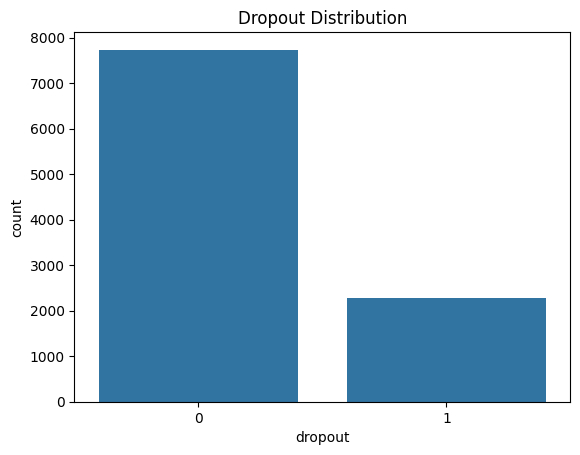

In [ ]:
sns.countplot(x='dropout', data=df)
plt.title("Dropout Distribution")
plt.show()

In [ ]:
df.to_csv("student_dropout_synthetic.csv", index=False)

In [ ]:
X = df.drop('dropout', axis=1)
y = df['dropout']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.844
Confusion Matrix:
 [[1434   99]
 [ 213  254]]


In [ ]:
print("✅ Model is ready. Now enter student details for prediction.\n")

✅ Model is ready. Now enter student details for prediction.



In [ ]:
print("Enter Student Details:")

attendance = float(input("Attendance (%): "))
study_hours = float(input("Study hours per day: "))
gpa = float(input("GPA (0-10): "))
classroom_interaction = float(input("Classroom interaction (0-10): "))
assignment_completion = float(input("Assignment completion (%): "))

# Create input DataFrame
user_data = [[
    attendance, study_hours, gpa,
    classroom_interaction, assignment_completion
]]

user_df = pd.DataFrame(user_data, columns=X.columns)

# Prediction
prediction = model.predict(user_df)[0]
probability = model.predict_proba(user_df)[0][1]

print("\n--- Prediction Result ---")

if prediction == 1:
    print("⚠️ High Risk of Dropout")
else:
    print("✅ Low Risk of Dropout")

print(f"Dropout Probability: {probability:.2f}")

Enter Student Details:
Attendance (%): 20
Study hours per day: 1
GPA (0-10): 3
Classroom interaction (0-10): 2
Assignment completion (%): 30

--- Prediction Result ---
⚠️ High Risk of Dropout
Dropout Probability: 1.00
